# Making training data

Here we take the various experiments that have been run and combine them into a single training dataset

# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# general libraries
import glob
import os
import pathlib
import site
import re
import sys
import warnings
from loguru import logger
# data handling libraries
import geopandas as gpd
import numpy as np
import pandas as pd
import rioxarray as rxr
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask
from tqdm.notebook import tqdm as ProgressBar
# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.xarray  # noqa: F401
# machine learning libraries
import gpytorch
from sklearn import gaussian_process as gp
import torch

import cryogrid_pytools as cg
import pamir_mlpermafrost as pamir

# Loading data

In [3]:
fname_spatial = f'simplecache::s3://spi-pamir-cryogrid/processed-cluster_config/spatial_variables-710w365s750e400n-100m.zarr/'

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Open the spatial variables dataset
    props = dict(storage_options=pamir.data.s3_utils.get_fsspec_s3_kwargs())
    ds_spatial = (
        xr.open_zarr(fname_spatial, **props)
        .rename(
            albedo_modis='albedo',
            emissivity_aster='emissivity', 
            skyview='skyview_factor',))

In [83]:
def open_data(exp):
    path_template = 's3://spi-pamir-cryogrid/cryogrid_runs_zarr/cryogrid_{level}-k1500-pamir_N180-exp{exp}.zarr/'
    s3_bucket = "/".join(path_template.split('/')[:3])

    fname_raw = path_template.format(exp=exp, level='raw')
    fname_summary = path_template.format(exp=exp, level='summary')

    props = dict(storage_options=pamir.data.s3_utils.get_fsspec_s3_kwargs())
    ds_raw = xr.open_zarr(fname_raw, **props)
    ds_summary = xr.open_zarr(fname_summary, **props)
    ds_summary = ds_summary.drop_vars('variable', errors='ignore')

    with ProgressBarDask(desc=f'Loading data from {s3_bucket}'):
        ds_summary['cluster_params'] = ds_raw['cluster_params'].load()
        ds_summary['cluster_labels'] = ds_raw['cluster_labels'].load()

        order_of_magnitude = 10 ** np.floor(np.log10(ds_summary.tag)).mean().item()
        ds_summary = ds_summary.assign_attrs(experiment=(ds_summary.tag // order_of_magnitude).median().astype(int).item())
        ds_summary['index'] = (ds_summary.tag % order_of_magnitude).astype(int)
        ds_summary = ds_summary.swap_dims({'tag': 'index'}).drop_vars('tag')
        ds_summary['cluster_params'] = ds_summary['cluster_params']

    return ds_summary


def get_table(data):
    da_table = data.cluster_params
    df_table = da_table.to_series().unstack().rename(columns={'latitude': 'y', 'longitude': 'x'})
    return df_table

In [ ]:
ds_profiles = open_data(5)
da_clusters = ds_profiles.cluster_labels
df_table = get_table(ds_profiles)
selector = df_table[['x', 'y']].to_xarray()

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/2 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/65 [00:00<?, ?it/s]

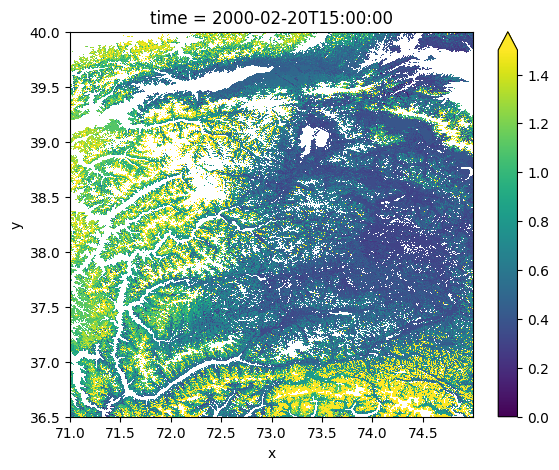

In [6]:
da = ds_profiles.snow_depth[:, 50].load()
cg.spatial_clusters.map_gridcells_to_clusters(da, da_clusters).plot.imshow(robust=True, size=5, aspect=1.3, vmax=1.5, vmin=0)

# ERA5 precip and temp quantiles

In [7]:
from sklearn import decomposition
from sklearn import preprocessing
from sklearn import pipeline

In [8]:
url_template = "s3://spi-pamir-c7-sdsc/era5_data/central_asia/central_asia-{year}.zarr/"
era5_central_asia_list = [
    xr.open_zarr(
        url_template.format(year=y), 
        storage_options=pamir.data.s3_utils.get_fsspec_s3_kwargs()) 
    for y in range(2000, 2025)]

era5_central_asia = xr.concat(era5_central_asia_list, dim='time')

era5_tajik = (
    era5_central_asia[['t2m', 'tp']]
    .sel(
        latitude=slice(40, 36.5),
        longitude=slice(70, 75),
        time=slice('2000', None))
    .rename(
        latitude='y',
        longitude='x',
        tp='precip',
        t2m='temp2m'
    )
)

In [9]:
def get_seasonal_quantiles(da, quantiles=[0.05, 0.5, 0.95], dim='time'):
    """
    Calculate seasonal quantiles for a given DataArray.
    
    Parameters:
        da (xr.DataArray): Input data array with a 'time' dimension.
        quantiles (list): List of quantiles to compute.
        dim (str): Dimension along which to compute the quantiles.
        
    Returns:
        xr.DataArray: DataArray containing the computed quantiles.
    """
    name = da.name
    
    out = (
        da.groupby(f'{dim}.season')
        .quantile(quantiles, dim=dim)
        .stack(stacked=['quantile', 'season'])
        .to_dataset(dim='stacked')
        .drop_vars(['quantile', 'season']))

    out = out.rename({
        (q, seas): f"{name}_{seas}_q{int(q*100):02d}" for q, seas in out.data_vars
    })

    return out

In [10]:
with ProgressBarDask(desc="Calculating seasonal quantiles for ERA5 data"):
    # Calculate seasonal quantiles for temperature and precipitation
    ds_era5_quantiles = (
        xr.merge(
            [get_seasonal_quantiles(era5_tajik.temp2m),
            get_seasonal_quantiles(era5_tajik.precip)])
        .astype('float32')
        .compute())
    
df_era5_quantiles = ds_era5_quantiles.to_dataframe()

Calculating seasonal quantiles for ERA5 data:   0%|          | 0/3768 [00:00<?, ?it/s]

In [11]:
df_era5_quantiles = ds_era5_quantiles.to_dataframe()

In [12]:
pca_model = pipeline.make_pipeline(
    preprocessing.StandardScaler(),
    decomposition.PCA(n_components=0.95, svd_solver='full'))
pca_model.fit(df_era5_quantiles)

n_components = pca_model.named_steps['pca'].n_components_
df_era5_quantiles_pca = pd.DataFrame(
    pca_model.transform(df_era5_quantiles),
    columns=[f"era5_temp2m_precip_PC{i+1}" for i in range(n_components)],
    index=df_era5_quantiles.index
)

da_era5_quantiles_pca = df_era5_quantiles_pca.to_xarray().to_array(dim='principal_component')
ds_era5_quantiles_pca_interp = da_era5_quantiles_pca.to_dataset(dim='principal_component').interp_like(ds_spatial, method='cubic').astype('float32').assign_attrs(
    description=(
        "PCA components of seasonal quantiles (5, 50, 95) of ERA5 temperature and "
        "precipitation data interpolated to spatial data grid using cubic interpolation. "
        "ERA5 data are first standardized and then PCA is applied to retain 95% of variance. "
        "The PCs are then interpolated to the spatial grid. "),
)
ds_era5_quantiles_pca_interp['pca_var_explained'] = xr.DataArray(
    pca_model.named_steps['pca'].explained_variance_ratio_,
    dims=['principal_component'],
    coords={'principal_component': range(1, n_components + 1)},
    attrs={'description': 'Variance explained by each PCA component'})

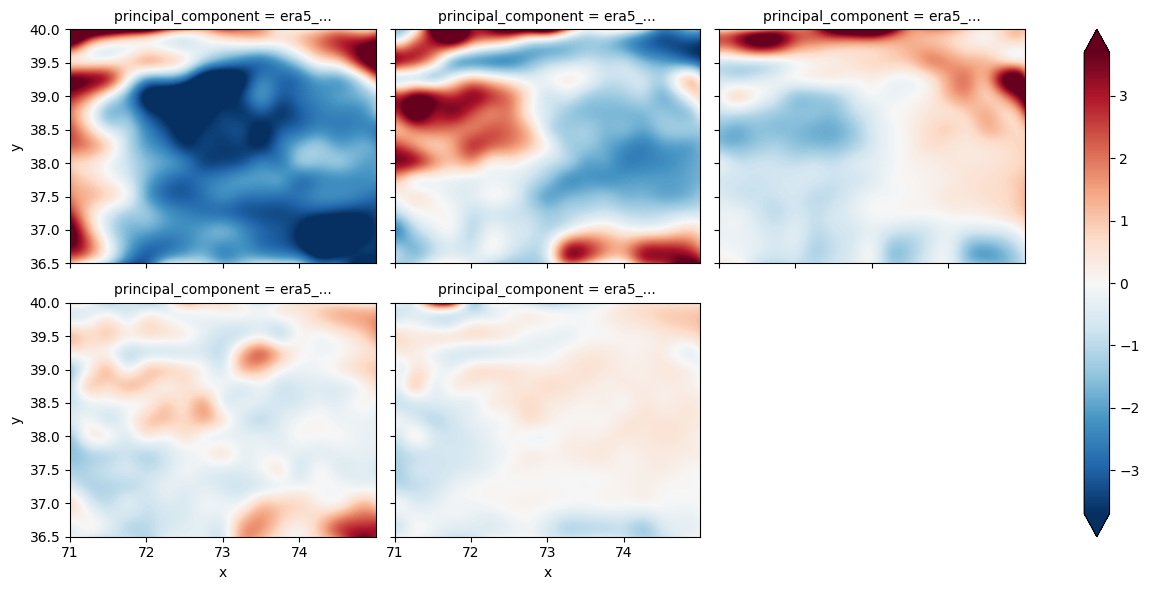

In [13]:
(
    ds_era5_quantiles_pca_interp
    .drop_vars('pca_var_explained')
    .to_dataarray(dim='principal_component')
    .plot.imshow(col='principal_component', col_wrap=3, size=3, aspect=1.3, robust=True)
)

In [14]:
ds_era5_quantiles_pca_interp.to_zarr('../../data/inference/era5_quantiles_pca_interp.zarr', mode='w', zarr_format=2)

In [15]:
ds_spatial = xr.merge([ds_spatial, ds_era5_quantiles_pca_interp.drop_vars(['pca_var_explained', 'principal_component'])])

# Collocating variables from spatial data

In [16]:
with ProgressBarDask(desc="Chunking and persisting spatial dataset"):
    ds_spatial_matching_names = (
        ds_spatial
        .drop_vars([
            'rock_glaciers', 
            'glaciers',
            'temperature_downscaled', 
            'spatial_ref'])
        .chunk({'x': 1000, 'y': 1000})
        .persist()
        .astype('float32')
    )

Chunking and persisting spatial dataset:   0%|          | 0/2540 [00:00<?, ?it/s]

In [17]:
df_spatial_matching_names = ds_spatial_matching_names.sel(selector, method='nearest').to_dataframe()

joined = df_table.join(df_spatial_matching_names, rsuffix='_spatial')
# filter out values ending with _spatial
pattern = r'^(?!.*_spatial$).*'
df_table_joined = joined.filter(regex=pattern)

In [18]:
a = sorted(df_table_joined.columns)
b = sorted(list(ds_spatial_matching_names.data_vars) + ['x', 'y'])
diff = list(set(a) - set(b))

In [41]:
ddf_spatial_matching_names = ds_spatial_matching_names.chunk({'x': 1000, 'y': 1000}).to_dask_dataframe().astype('float32')

In [ ]:
fname_pq = '../../data/inference/inference_data-pamir_N180-matching_names-v20250916.parquet'
ddf_spatial_matching_names.to_parquet(fname_pq, overwrite=True)

# Reading in data

In [86]:
import dask.dataframe as dd

In [100]:
fname_pq_s3 = "s3://spi-pamir-cryogrid/pamir-MLpermafrost/data-inference/inference_data-pamir_N180-matching_names-v20250916.parquet/"
ddf = dd.read_parquet(fname_pq_s3, storage_options=pamir.data.s3_utils.get_fsspec_s3_kwargs()).drop(columns=['surface_index'])

In [101]:
ds_spatial = ddf.compute().set_index(['y', 'x']).to_xarray()

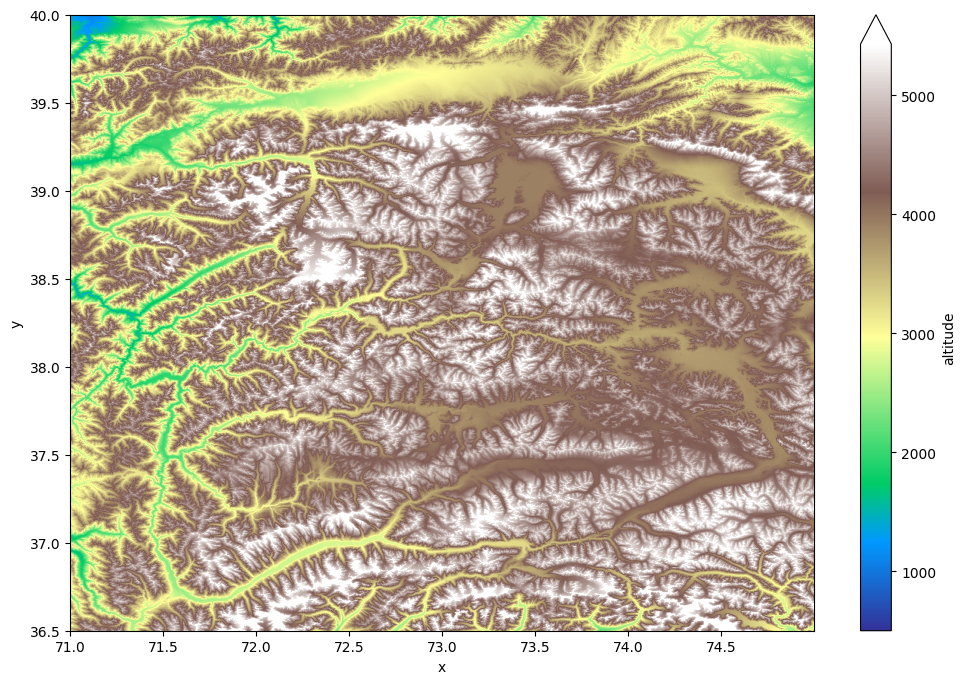

In [102]:
ds_spatial.altitude.plot.imshow(aspect=1.5, size=8, robust=True, cmap='terrain', vmin=500)

In [126]:
df_tables_joined = []
for exp in [1, 2, 4, 5, 6]:
    ds_profiles = open_data(1)
    df_table = get_table(ds_profiles).assign(exp=exp)
    selector = df_table[['x', 'y']].to_xarray()

    keys_table = set(df_table.columns.tolist())
    keys_array = set(ds_spatial.data_vars)
    keys_to_transfer_to_table = keys_array - keys_table

    df_spatial_matched = ds_spatial[keys_to_transfer_to_table].sel(selector, method='nearest').to_dataframe().drop(columns=['x', 'y'])

    df_tables_joined += df_table.join(df_spatial_matched, rsuffix='_spatial', ),

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/2 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/129 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/2 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/129 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/2 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/129 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/2 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/129 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/2 [00:00<?, ?it/s]

Loading data from s3://spi-pamir-cryogrid:   0%|          | 0/129 [00:00<?, ?it/s]

In [130]:
df_table_joined = pd.concat(df_tables_joined, axis=0).reset_index().set_index(['exp', 'index'])
df_table_joined.to_parquet('../../data/training/training_data-k1500-pamir_N180-era5PCA.parquet')

In [133]:
df_table_joined

y          x     altitude  slope_angle     aspect  \
exp index                                                              
1   1      36.980571  73.632165  4330.637695    34.567669  286.57617   
    2      36.662839  72.924405  3833.701904    34.909039  210.50952   
    3      37.323505  72.426655  4095.381104    24.368822  278.70193   
    4      37.442317  71.125345  3389.325684    24.351332   88.22772   
    5      39.831371  72.655278  4193.701172    17.092854  230.25931   
...              ...        ...          ...          ...        ...   
6   1496   39.438433  71.460179  3812.707520    18.764854   40.27780   
    1497   37.024675  72.269139  4820.770020    31.149490  304.45837   
    1498   36.881561  71.254058  4413.031738    19.424364   88.47595   
    1499   38.555445  71.620395  3369.283936    35.103275  346.53030   
    1500   36.886962  74.583754  4299.495117    33.536999  356.95880   

           skyview_factor  stratigraphy_index    albedo  emissivity  \
exp index                                                             
1   1            0.768356                 1.0  0.074727    0.946151   
    2            0.785660                 4.0  0.084380    0.956691   
    3            0.874698                 3.0  0.152000    0.944333   
    4            0.875992                 4.0  0.116722    0.962079   
    5            0.697091                 3.0  0.166600    0.960267   
...                   ...                 ...       ...         ...   
6   1496         0.848582                 4.0  0.160672    0.957765   
    1497         0.828178                 4.0  0.132692    0.956402   
    1498         0.722326                 3.0  0.133115    0.958163   
    1499         0.726106                 4.0  0.104333    0.954839   
    1500         0.760421                 1.0  0.098531    0.927015   

           roughness_length  precip_scaling  era5_temp2m_precip_PC5  \
exp index                                                             
1   1                  0.05             0.5               -0.053673   
    2                  0.04             0.5               -0.364131   
    3                  0.04             0.5                0.019235   
    4                  0.04             0.5               -1.038213   
    5                  0.04             0.5                0.106002   
...                     ...             ...                     ...   
6   1496               0.04             0.5                0.338882   
    1497               0.04             0.5                0.022077   
    1498               0.04             0.5               -0.246129   
    1499               0.04             0.5               -0.350872   
    1500               0.05             0.5               -0.162703   

           era5_temp2m_precip_PC2  era5_temp2m_precip_PC1  temperature  \
exp index                                                                
1   1                    0.730325               -3.062303   263.205811   
    2                   -0.818152               -2.212234   264.656250   
    3                   -0.516647               -2.623621   263.860535   
    4                    0.153778                1.492034   270.054169   
    5                    0.575231               -0.206994   268.122925   
...                           ...                     ...          ...   
6   1496                 0.443905                1.119083   270.959198   
    1497                -0.338106               -2.181016   264.486725   
    1498                -1.421329                1.864302   271.902527   
    1499                 2.445096               -1.099929   266.147369   
    1500                 1.375963               -4.747769   260.297760   

           era5_temp2m_precip_PC3  era5_temp2m_precip_PC4  precipitation  \
exp index                                                                  
1   1                   -0.698269                0.960317       0.000065   
    2                   -0.158188          